In [31]:
import pandas as pd

In [32]:
df = pd.read_csv("/home/vaibhav/Gemstone_Price/artifacts/train.csv")
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,17070,1.01,Premium,E,VVS1,62.5,60.0,6.45,6.41,4.01,10053
1,71777,1.30,Premium,E,SI2,60.3,59.0,7.11,7.05,4.24,6296
2,177525,0.27,Ideal,E,VS1,61.5,57.0,4.15,4.18,2.56,577
3,30241,0.30,Ideal,F,IF,62.4,56.0,4.30,4.32,2.69,914
4,100756,0.72,Ideal,H,VVS1,61.9,56.0,5.75,5.79,3.57,3223


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191637 entries, 0 to 191636
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       191637 non-null  int64  
 1   carat    191637 non-null  float64
 2   cut      191637 non-null  object 
 3   color    191637 non-null  object 
 4   clarity  191637 non-null  object 
 5   depth    191637 non-null  float64
 6   table    191637 non-null  float64
 7   x        191637 non-null  float64
 8   y        191637 non-null  float64
 9   z        191637 non-null  float64
 10  price    191637 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.1+ MB


In [34]:
df = df.drop(labels=['id'],axis=1)

In [35]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
numerical_columns = list(df.columns[df.dtypes!='object'])
categorical_columns = list(df.columns[df.dtypes=='object'])
print(f'Numerical Columns   : {numerical_columns}')
print(f'Categorical Columns : {categorical_columns}')

Numerical Columns   : ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
Categorical Columns : ['cut', 'color', 'clarity']


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,191637.0,0.790601,0.462577,0.2,0.40,0.70,1.03,3.50
depth,191637.0,61.821127,1.081799,52.1,61.30,61.90,62.40,71.60
table,191637.0,57.228024,1.918868,49.0,56.00,57.00,58.00,79.00
x,191637.0,5.715092,1.109278,0.0,4.70,5.70,6.51,9.65
y,191637.0,5.719881,1.102191,0.0,4.71,5.72,6.51,10.01
z,191637.0,3.534150,0.688921,0.0,2.90,3.53,4.03,31.30
price,191637.0,3968.521048,4033.840436,326.0,950.00,2401.00,5407.00,18818.00


In [39]:
df[categorical_columns].describe().T

,count,unique,top,freq
cut,191637,5,Ideal,91515
color,191637,7,G,43958
clarity,191637,8,SI1,52750


In [40]:
df.nunique()

carat       247
cut           5
color         7
clarity       8
depth       153
table       108
x           522
y           521
z           348
price      8738
dtype: int64

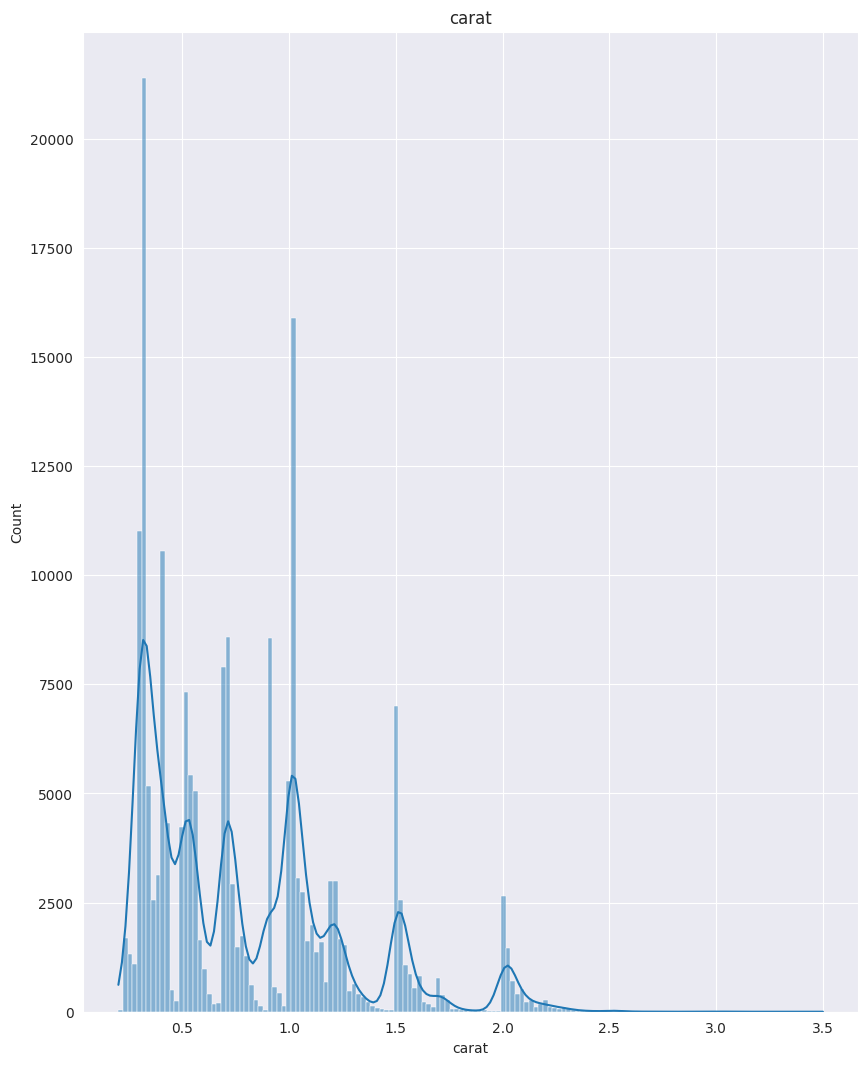

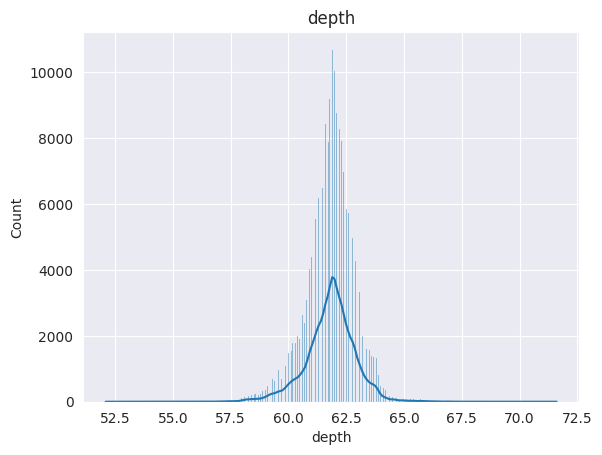

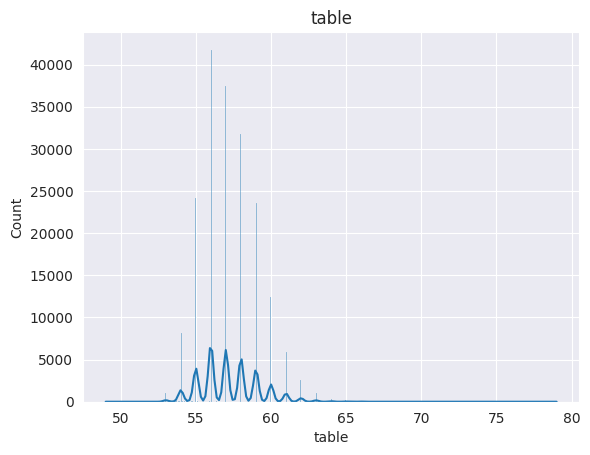

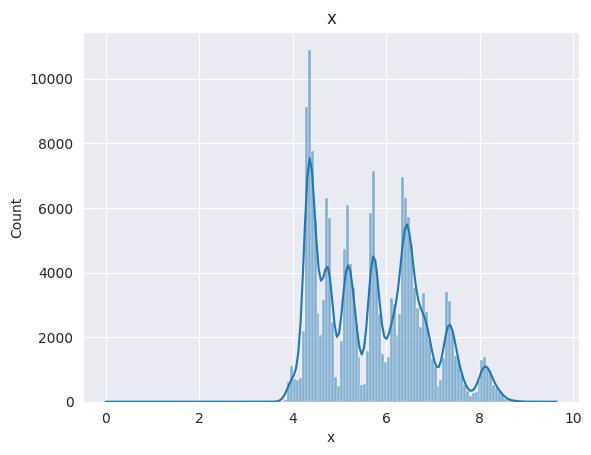

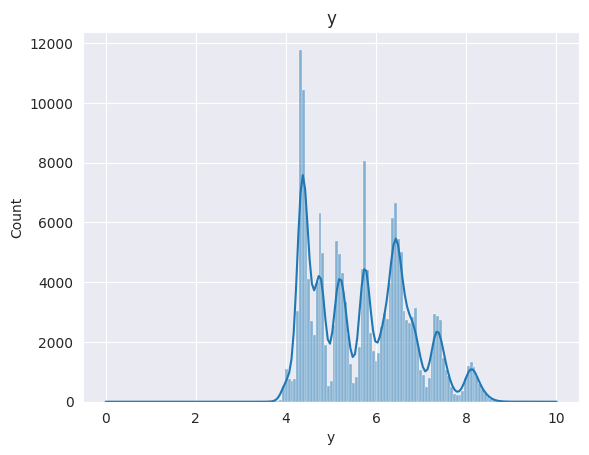

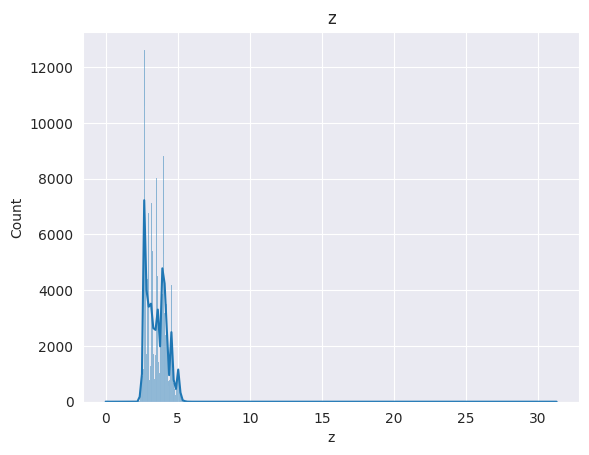

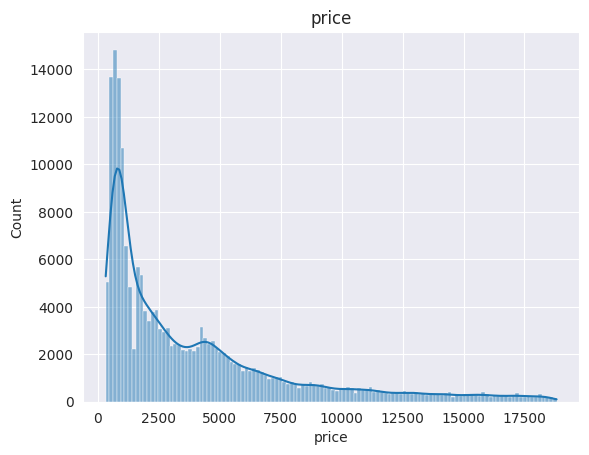

In [41]:
import seaborn as sb
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.5, wspace=0.5)
x = 1
for i in numerical_columns:
    sb.histplot(data = df, x = i, kde=True)
    plt.title(i)
    print('\n')
    plt.show()

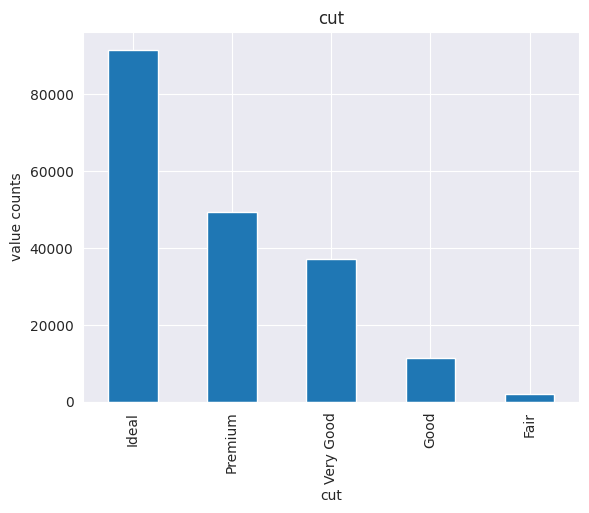

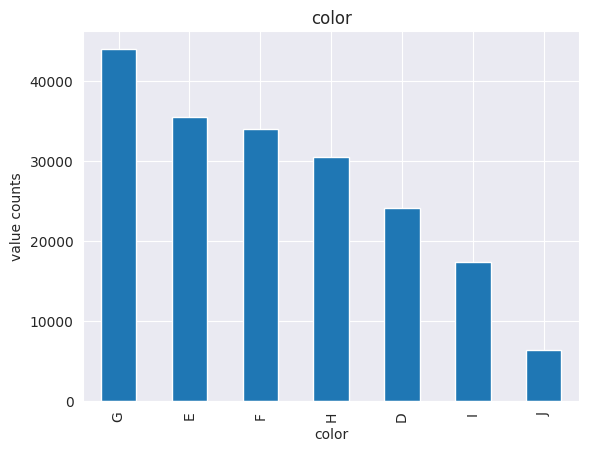

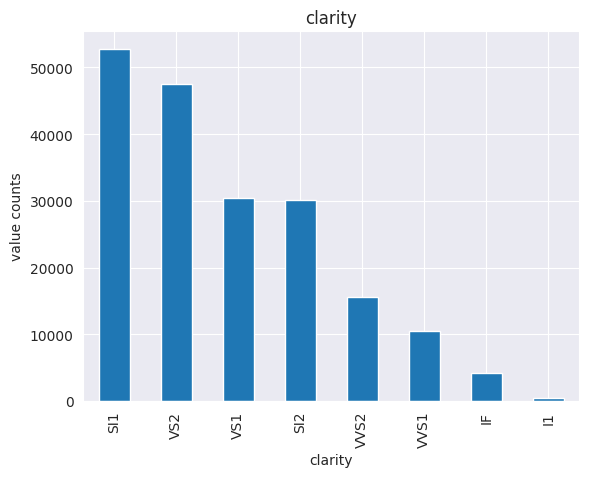

In [42]:
for i in categorical_columns:
    df[i].value_counts().plot(kind='bar', xlabel = i , ylabel='value counts', title = i)
    print('\n')
    plt.show()

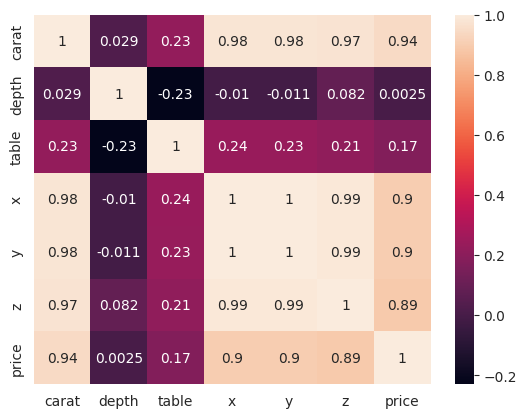

In [43]:
sb.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

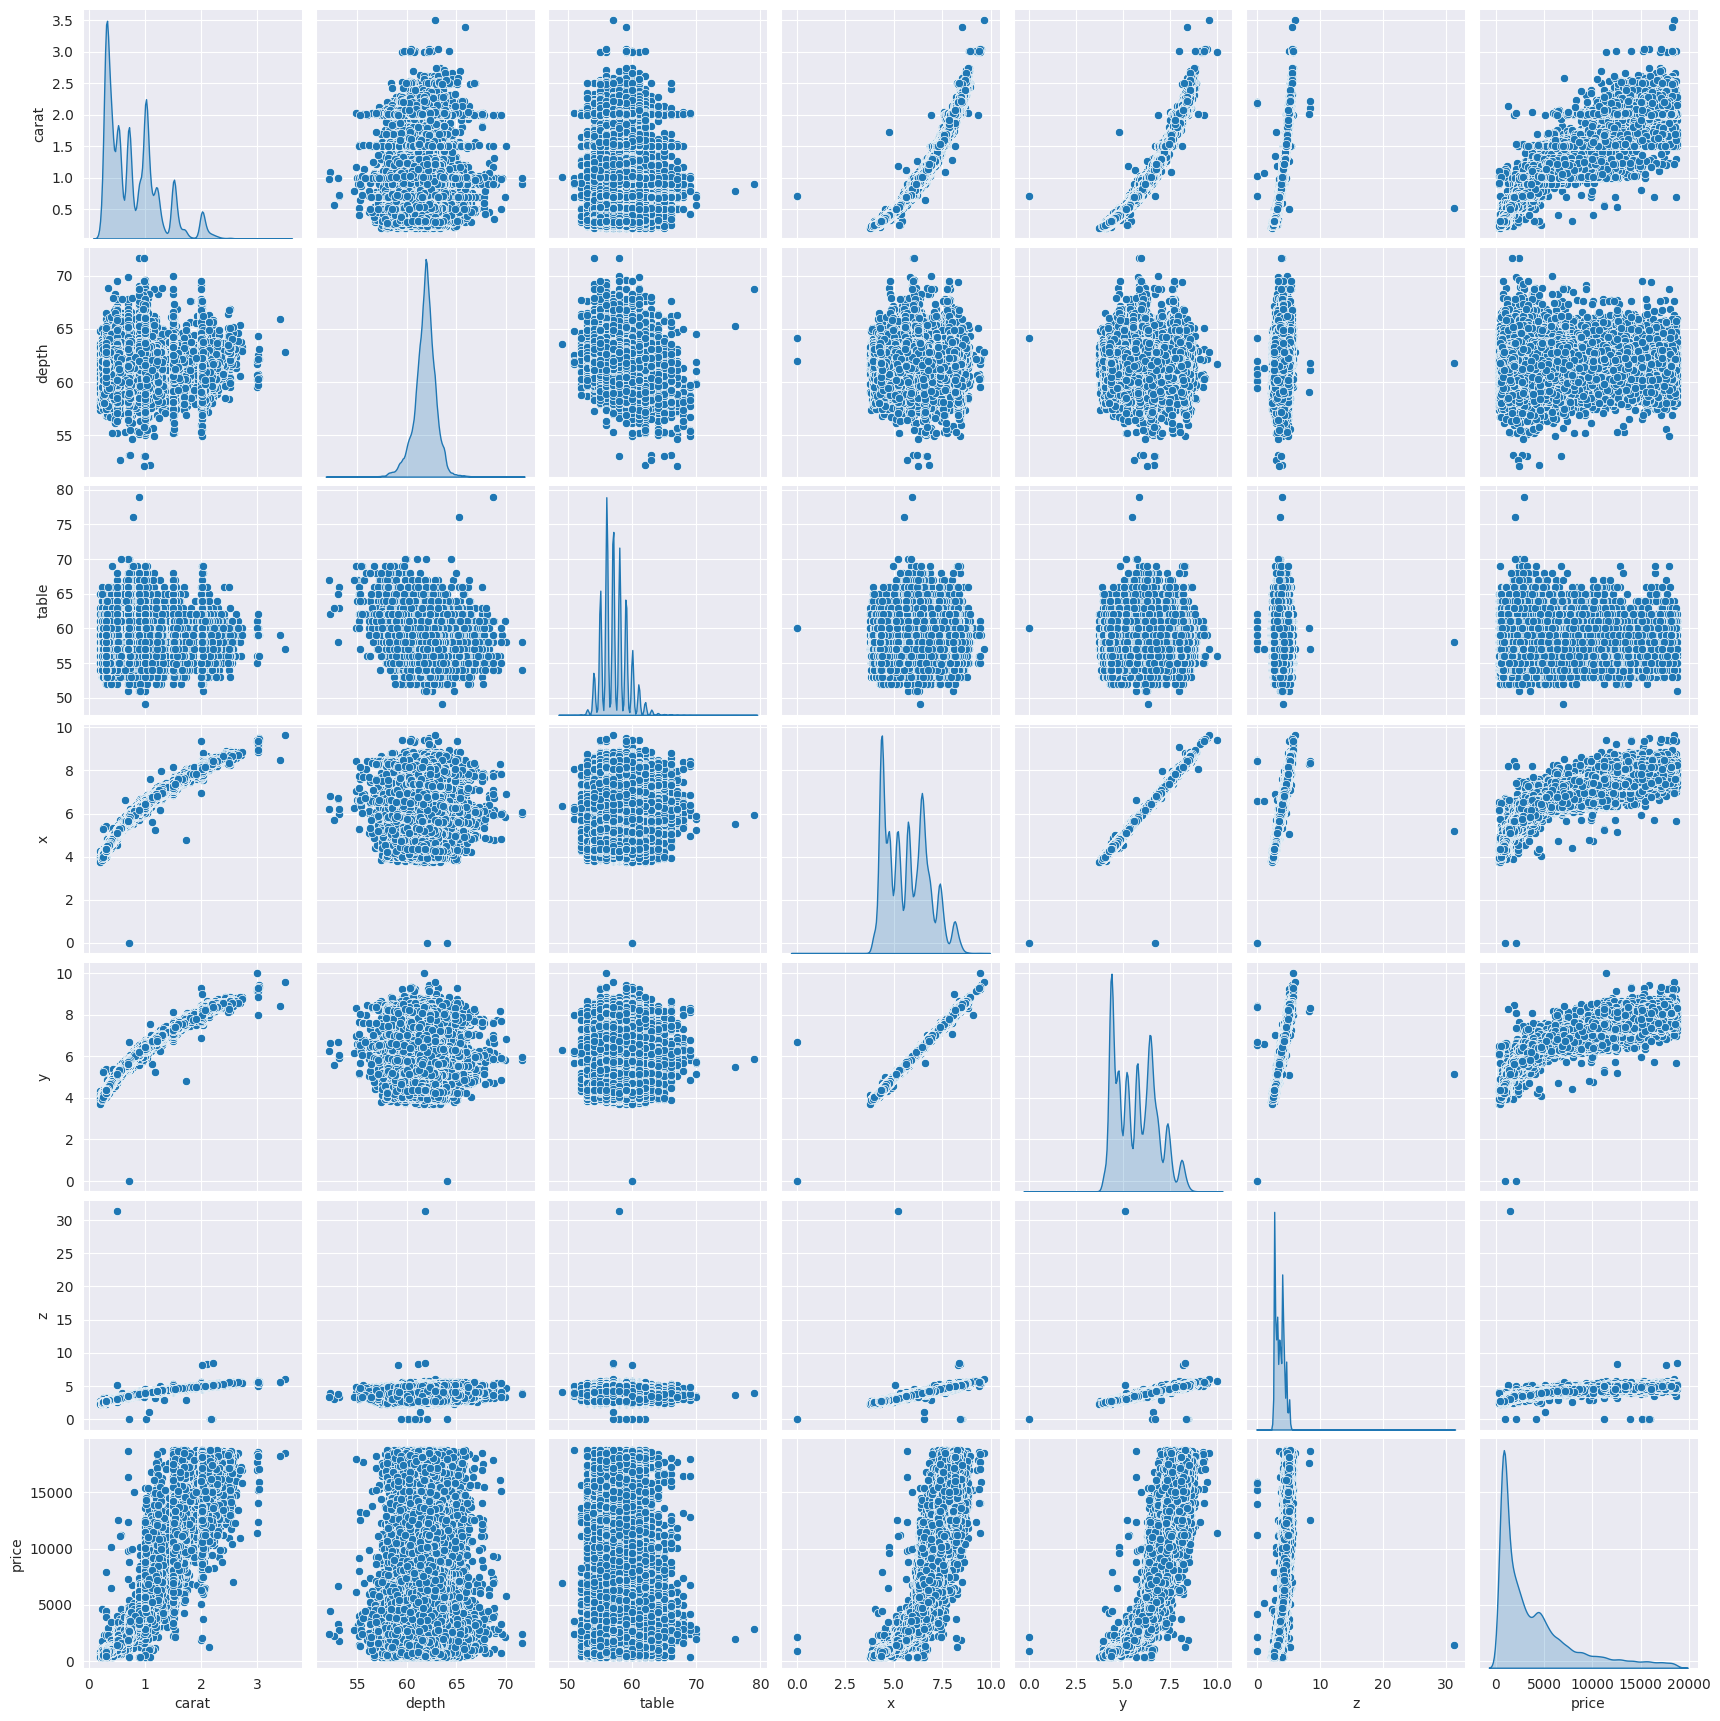

In [44]:
sb.pairplot(df,diag_kind='kde')
plt.show()

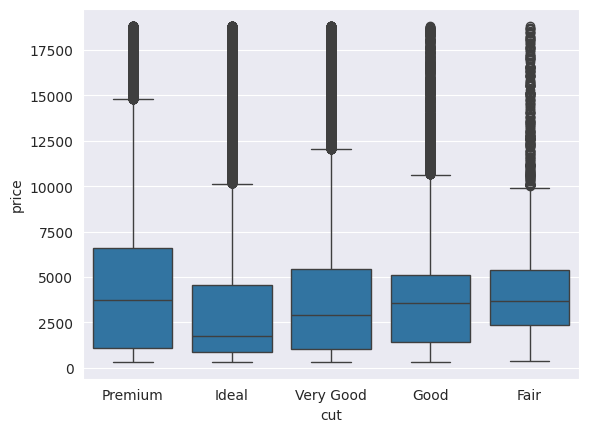

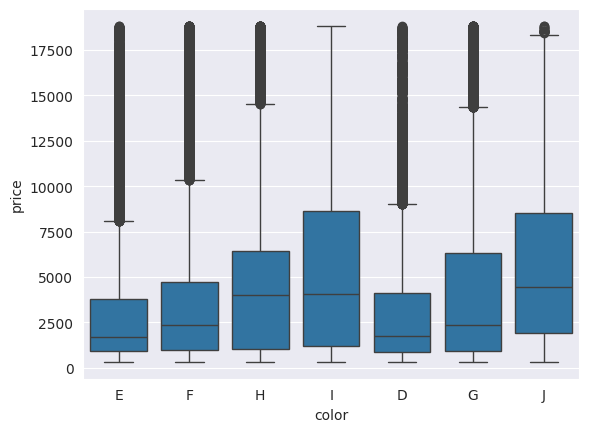

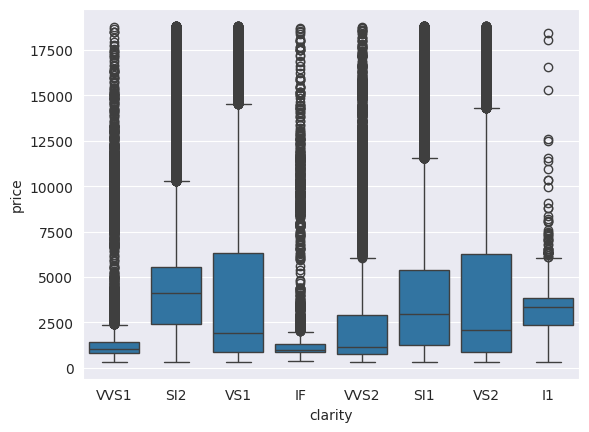

In [45]:
for i in categorical_columns:
    sb.boxplot(data=df, x=i , y='price')
    plt.show()

In [46]:
cut_mapper = {"Fair":1, "Good":2, "Very Good":3 , "Premium":4 ,"Ideal":5}
clarity_mapper = {"I1":1,"SI2":2 ,"SI1":3 ,"VS2":4 , "VS1":5 , "VVS2":6 , "VVS1":7 ,"IF":8}
color_mapper = {"D":1 ,"E":2 ,"F":3 , "G":4 ,"H":5 , "I":6, "J":7}

In [47]:
df['cut'] = df['cut'].replace(cut_mapper)
df['clarity'] = df['clarity'].replace(clarity_mapper)
df['color'] = df['color'].replace(color_mapper)

/tmp/ipykernel_58045/967689762.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cut'] = df['cut'].replace(cut_mapper)
/tmp/ipykernel_58045/967689762.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clarity'] = df['clarity'].replace(clarity_mapper)
/tmp/ipykernel_58045/967689762.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option(

In [48]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.01,4,2,7,62.5,60.0,6.45,6.41,4.01,10053
1,1.30,4,2,2,60.3,59.0,7.11,7.05,4.24,6296
2,0.27,5,2,5,61.5,57.0,4.15,4.18,2.56,577
3,0.30,5,3,8,62.4,56.0,4.30,4.32,2.69,914
4,0.72,5,5,7,61.9,56.0,5.75,5.79,3.57,3223


In [49]:
X = df.drop(labels=['price'],axis=1)
Y = df[['price']]


In [50]:
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X,Y.values.flatten(),random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores",index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)


In [51]:
mi_scores

carat      1.826171
x          1.673545
y          1.666755
z          1.618029
clarity    0.397481
color      0.284925
table      0.110999
cut        0.090834
depth      0.046624
Name: MI Scores, dtype: float64

In [52]:
import numpy as np

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    plt.show()


carat      1.826171
x          1.673545
y          1.666755
z          1.618029
clarity    0.397481
color      0.284925
table      0.110999
cut        0.090834
depth      0.046624
Name: MI Scores, dtype: float64


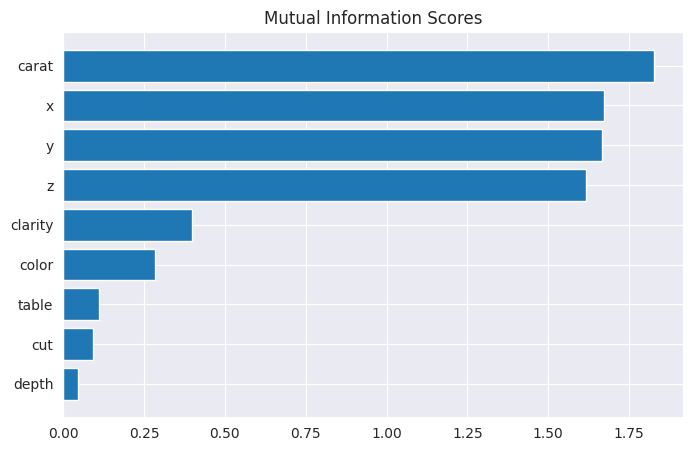

In [53]:
print(mi_scores)
plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

Conclusion : Above shows that carat and x, y, z are most important features to predict the price of a gemstone